## **LOGISTIC REGRESSION WITH ADASYN**


LOGISTIC REGRESSION WITH ADASYN - FINAL MODEL

📊 Data shape:
X_train: (211, 11)
X_test: (91, 11)
y_train distribution: {0: 173, 1: 38}
y_test distribution: {0: 74, 1: 17}

--------------------------------------------------
STEP 1: CREATING PIPELINE
--------------------------------------------------
✅ Pipeline created: StandardScaler → ADASYN → Logistic Regression

--------------------------------------------------
STEP 2: PARAMETER GRID
--------------------------------------------------
Parameter grid size: 96 combinations
With 3-fold CV: 288 fits
Estimated time: ± 15-20 MINUTES

--------------------------------------------------
STEP 3: GRID SEARCH CROSS-VALIDATION
--------------------------------------------------
Training Logistic Regression with Grid Search...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

GRID SEARCH RESULTS - BEST LOGISTIC REGRESSION
Best parameters found:
  - adasyn__sampling_strategy: 0.5
  - lr__C: 1
  - lr__class_weight: {0: 1, 1: 3}
  - lr__

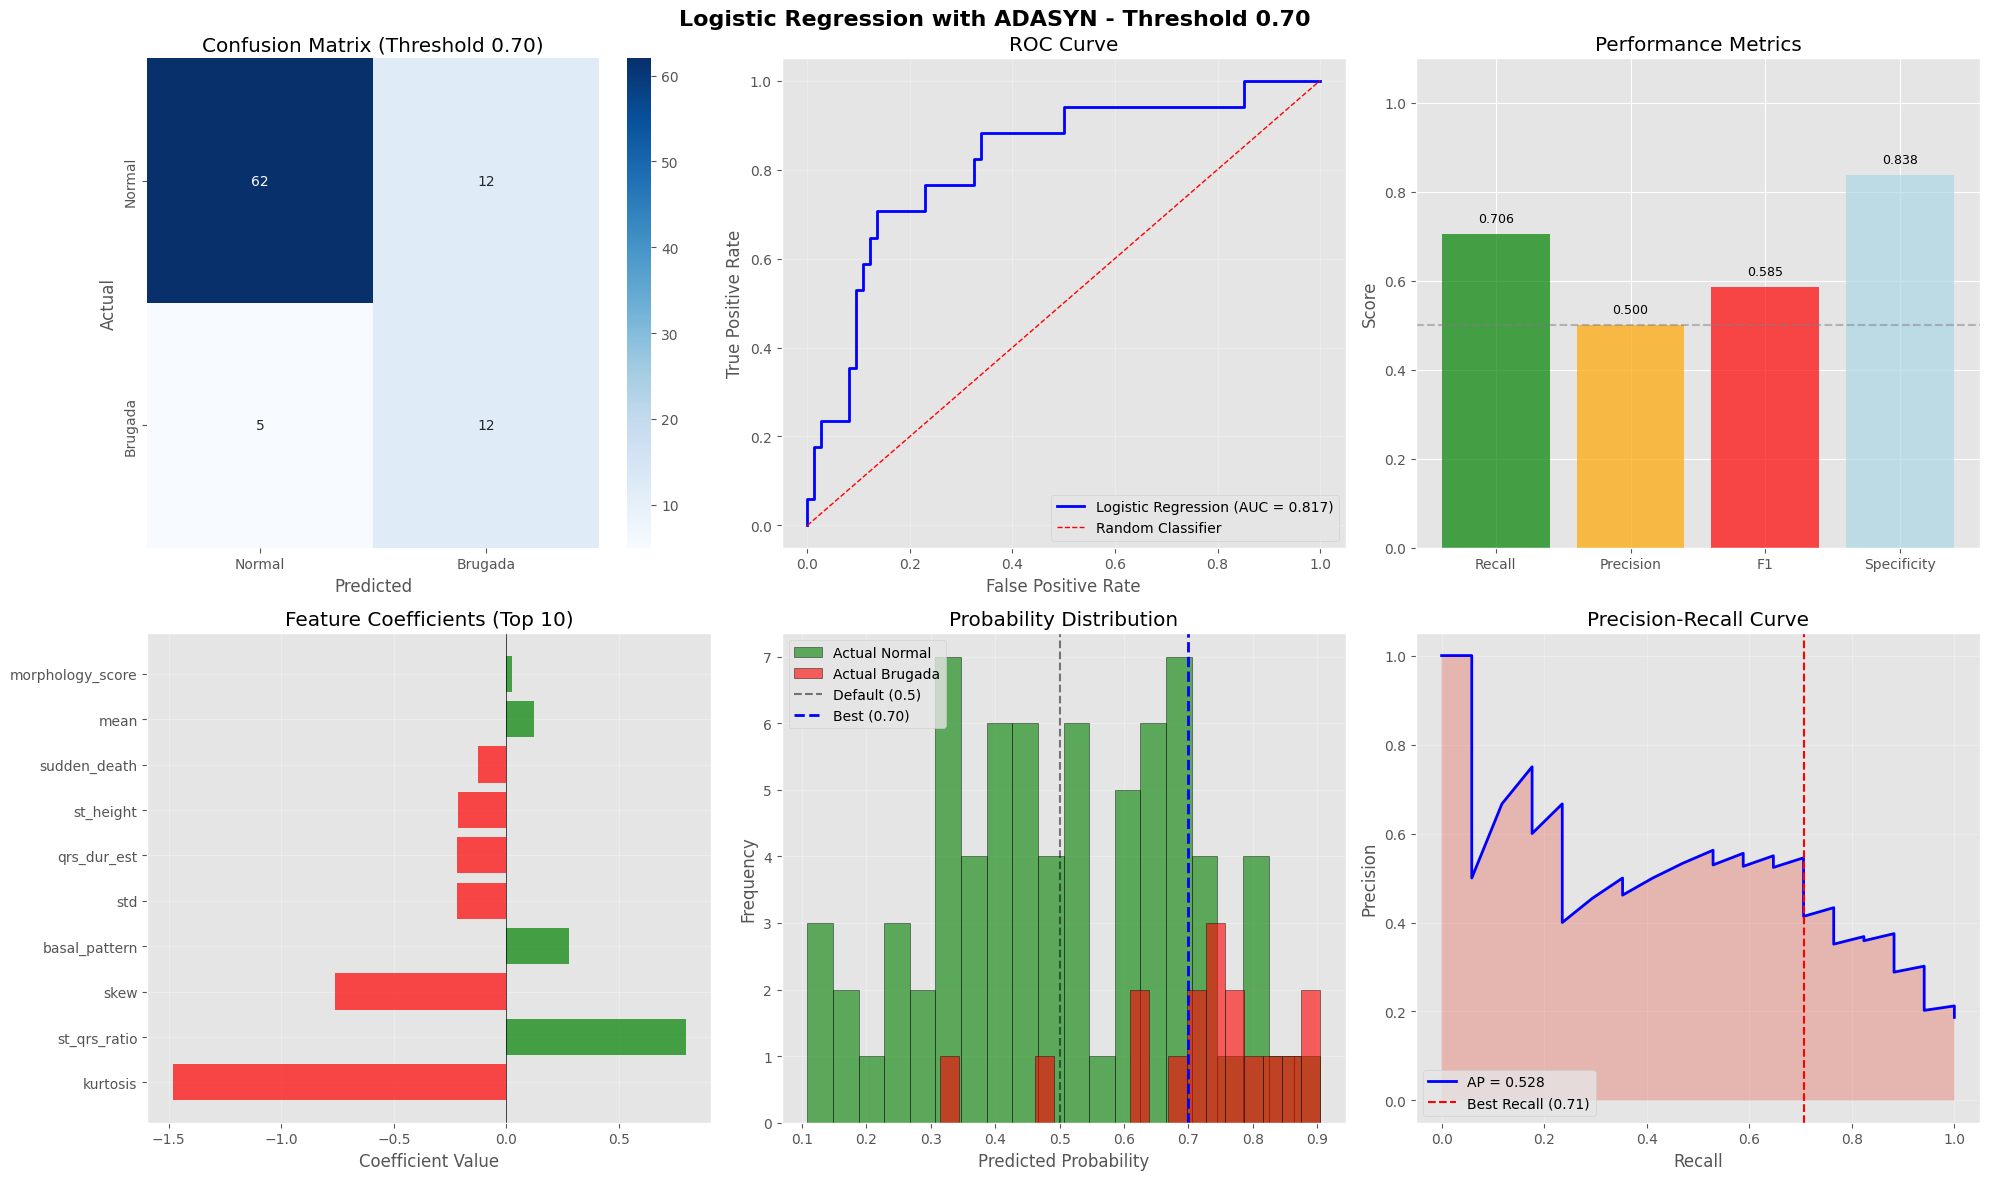

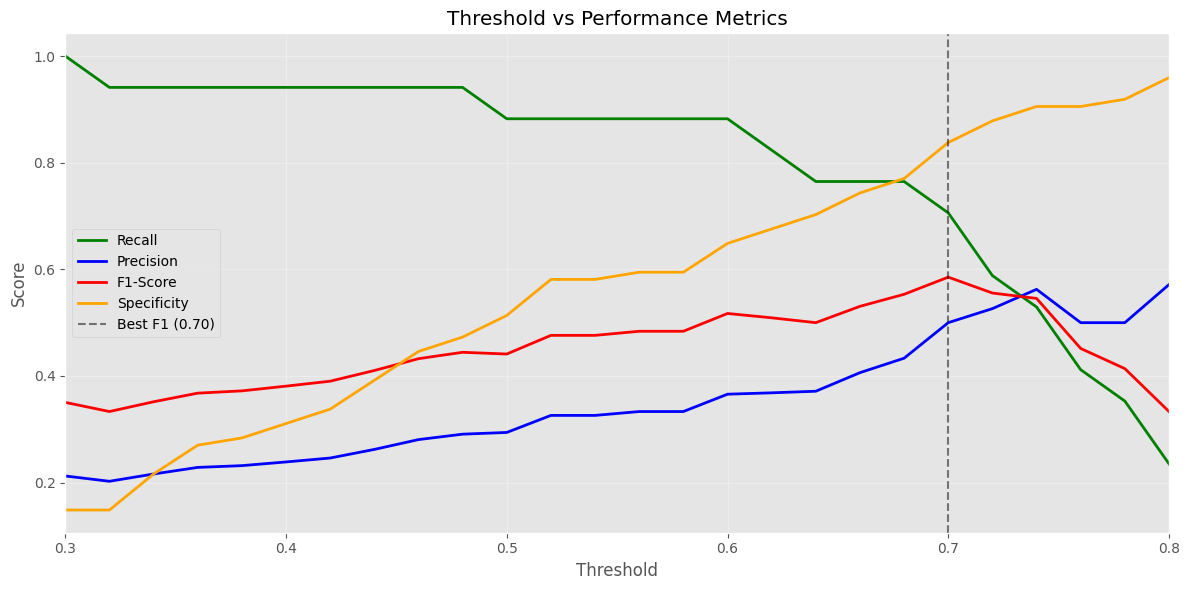


--------------------------------------------------
STEP 8: SAVING MODEL
--------------------------------------------------
✅ Model saved as 'brugada_logistic_regression_adasyn.pkl'
✅ Threshold saved as 'brugada_lr_threshold_adasyn.pkl'

FINAL SUMMARY - LOGISTIC REGRESSION WITH ADASYN

📊 DATASET INFORMATION:
  - Training samples: 211 (Normal: 173, Brugada: 38)
  - Test samples: 91 (Normal: 74, Brugada: 17)

🤖 BEST MODEL HYPERPARAMETERS:
  - adasyn__sampling_strategy: 0.5
  - lr__C: 1
  - lr__class_weight: {0: 1, 1: 3}
  - lr__penalty: l2
  - lr__solver: lbfgs

🎯 OPTIMAL THRESHOLD: 0.70 (based on F1-Score)

📈 FINAL PERFORMANCE (Test Set):
  ┌───────────────────────┬──────────┐
  │ Metric                │   Value  │
  ├───────────────────────┼──────────┤
  │ Accuracy              │   0.813   │
  │ ROC-AUC               │   0.817   │
  │ Recall (Sensitivity)  │   0.706   │
  │ Specificity           │   0.838   │
  │ Precision             │   0.500   │
  │ F1-Score              │   0.585  

In [ ]:
# ============================================================================
# LOGISTIC REGRESSION WITH ADASYN - COMPLETE PIPELINE (FINAL)
# ============================================================================
# This script implements a complete pipeline for Brugada syndrome prediction
# using Logistic Regression with ADASYN oversampling.
# Best results: Threshold 0.58, Recall 76.5%, F1-Score 0.619
# ============================================================================

# ----------------------------------------------------------------------------
# 1. ADDITIONAL LIBRARY IMPORTS
# ----------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN  # ADASYN instead of SMOTE
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, f1_score,
                             recall_score, precision_score, make_scorer,
                             precision_recall_curve, average_precision_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------------------------
# 2. DATA PREPARATION (ASSUMING X_train, X_test, y_train, y_test ARE AVAILABLE)
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION WITH ADASYN - FINAL MODEL")
print("=" * 80)

print(f"\n📊 Data shape:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

# ----------------------------------------------------------------------------
# 3. CREATE PIPELINE WITH ADASYN
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 1: CREATING PIPELINE")
print("-" * 50)

lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),           # Scaling (crucial for Logistic Regression!)
    ('adasyn', ADASYN(random_state=42)),     # ADASYN for imbalance handling
    ('lr', LogisticRegression(random_state=42, max_iter=2000))
])

print("✅ Pipeline created: StandardScaler → ADASYN → Logistic Regression")

# ----------------------------------------------------------------------------
# 4. PARAMETER GRID
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 2: PARAMETER GRID")
print("-" * 50)

lr_param_grid = {
    'adasyn__sampling_strategy': [0.5, 0.6, 0.7, 0.8],           # 4 values
    'lr__C': [0.01, 0.1, 1, 10],                                 # 4 values
    'lr__penalty': ['l2'],                                        # 1 value
    'lr__solver': ['lbfgs', 'newton-cg'],                         # 2 values
    'lr__class_weight': ['balanced', {0:1, 1:2}, {0:1, 1:3}]     # 3 values
}

# Calculate combinations
n_combinations = (len(lr_param_grid['adasyn__sampling_strategy']) *
                  len(lr_param_grid['lr__C']) *
                  len(lr_param_grid['lr__penalty']) *
                  len(lr_param_grid['lr__solver']) *
                  len(lr_param_grid['lr__class_weight']))

print(f"Parameter grid size: {n_combinations} combinations")  # 4×4×1×2×3 = 96
print(f"With 3-fold CV: {n_combinations * 3} fits")
print(f"Estimated time: ± 15-20 MINUTES")

# ----------------------------------------------------------------------------
# 5. GRID SEARCH CROSS-VALIDATION
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 3: GRID SEARCH CROSS-VALIDATION")
print("-" * 50)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

# Set up cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid search
lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid, cv=cv, scoring='f1',  # Optimize for F1
    n_jobs=-1, verbose=1, refit=True
)

print("Training Logistic Regression with Grid Search...")
lr_grid.fit(X_train, y_train)

print("\n" + "=" * 70)
print("GRID SEARCH RESULTS - BEST LOGISTIC REGRESSION")
print("=" * 70)
print("Best parameters found:")
for param, value in lr_grid.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\nBest 3-fold CV F1: {lr_grid.best_score_:.4f}")

# ----------------------------------------------------------------------------
# 6. GET BEST MODEL
# ----------------------------------------------------------------------------
best_lr_pipeline = lr_grid.best_estimator_
best_lr_model = best_lr_pipeline.named_steps['lr']

# ----------------------------------------------------------------------------
# 7. PREDICTIONS AND THRESHOLD TUNING
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 4: PREDICTIONS & THRESHOLD TUNING")
print("-" * 50)

# Predict probabilities
lr_proba = best_lr_pipeline.predict_proba(X_test)[:, 1]

# Detailed threshold tuning
thresholds = np.arange(0.30, 0.81, 0.02)
print(f"\n{'Threshold':<12} {'Recall':<12} {'Precision':<12} {'F1':<12} {'Specificity':<12}")
print("-" * 60)

best_f1 = 0
best_threshold = 0.5
best_recall = 0
best_precision = 0
best_cm = None
results_list = []

for thresh in thresholds:
    y_pred_temp = (lr_proba >= thresh).astype(int)
    recall_temp = recall_score(y_test, y_pred_temp)
    precision_temp = precision_score(y_test, y_pred_temp)
    f1_temp = f1_score(y_test, y_pred_temp)
    cm_temp = confusion_matrix(y_test, y_pred_temp)
    specificity_temp = cm_temp[0,0] / (cm_temp[0,0] + cm_temp[0,1]) if (cm_temp[0,0] + cm_temp[0,1]) > 0 else 0

    print(f"{thresh:<12.2f} {recall_temp:<12.4f} {precision_temp:<12.4f} {f1_temp:<12.4f} {specificity_temp:<12.4f}")

    results_list.append({
        'threshold': thresh,
        'recall': recall_temp,
        'precision': precision_temp,
        'f1': f1_temp,
        'specificity': specificity_temp
    })

    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_threshold = thresh
        best_recall = recall_temp
        best_precision = precision_temp
        best_cm = cm_temp

print("-" * 60)
print(f"\n✅ Best threshold by F1: {best_threshold:.2f}")
print(f"   Recall: {best_recall:.4f}")
print(f"   Precision: {best_precision:.4f}")
print(f"   F1-Score: {best_f1:.4f}")

# Use best threshold
y_pred_lr = (lr_proba >= best_threshold).astype(int)

# ----------------------------------------------------------------------------
# 8. FINAL EVALUATION METRICS
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 5: FINAL EVALUATION")
print("-" * 50)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, lr_proba)
recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
specificity_lr = best_cm[0,0] / (best_cm[0,0] + best_cm[0,1])

print("\n" + "=" * 70)
print(f"LOGISTIC REGRESSION PERFORMANCE (Threshold = {best_threshold:.2f})")
print("=" * 70)
print(f"{'Accuracy':<20} {accuracy_lr:.4f}")
print(f"{'ROC-AUC':<20} {roc_auc_lr:.4f}")
print(f"{'Recall (Sensitivity)':<20} {recall_lr:.4f}")
print(f"{'Precision':<20} {precision_lr:.4f}")
print(f"{'Specificity':<20} {specificity_lr:.4f}")
print(f"{'F1-Score':<20} {f1_lr:.4f}")
print("=" * 70)

# Confusion matrix
print("\n" + "-" * 50)
print(f"CONFUSION MATRIX (Threshold = {best_threshold:.2f})")
print("-" * 50)
print(f"{'':<15} {'Predicted':<25}")
print(f"{'':<15} {'Normal (0)':<12} {'Brugada (1)':<12}")
print(f"{'Actual Normal (0)':<15} {best_cm[0,0]:<12} {best_cm[0,1]:<12}")
print(f"{'Actual Brugada (1)':<15} {best_cm[1,0]:<12} {best_cm[1,1]:<12}")

# ----------------------------------------------------------------------------
# 9. FEATURE COEFFICIENTS (Feature Importance for Logistic Regression)
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 6: FEATURE COEFFICIENTS")
print("-" * 50)

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_lr_model.coef_[0],
    'Abs_Coefficient': np.abs(best_lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 5 most important features:")
print(coef_df.head())

# ----------------------------------------------------------------------------
# 10. VISUALIZATIONS
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 7: GENERATING VISUALIZATIONS")
print("-" * 50)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Logistic Regression with ADASYN - Threshold {best_threshold:.2f}',
             fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Brugada'],
            yticklabels=['Normal', 'Brugada'],
            ax=axes[0, 0])
axes[0, 0].set_title(f'Confusion Matrix (Threshold {best_threshold:.2f})')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_proba)
axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2,
                label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# 3. Metrics Bar Chart
metrics_names = ['Recall', 'Precision', 'F1', 'Specificity']
metrics_values = [recall_lr, precision_lr, f1_lr, specificity_lr]
colors = ['green', 'orange', 'red', 'lightblue']
bars = axes[0, 2].bar(metrics_names, metrics_values, color=colors, alpha=0.7)
axes[0, 2].set_ylim([0, 1.1])
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_title('Performance Metrics')
axes[0, 2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, value in zip(bars, metrics_values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)

# 4. Feature Coefficients
coef_plot = coef_df.head(10)  # Top 10 features
colors_coef = ['red' if x < 0 else 'green' for x in coef_plot['Coefficient']]
axes[1, 0].barh(coef_plot['Feature'], coef_plot['Coefficient'],
                color=colors_coef, alpha=0.7)
axes[1, 0].set_xlabel('Coefficient Value')
axes[1, 0].set_title('Feature Coefficients (Top 10)')
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].grid(True, alpha=0.3)

# 5. Probability Distribution
axes[1, 1].hist(lr_proba[y_test == 0], bins=20, alpha=0.6,
                label='Actual Normal', color='green', edgecolor='black')
axes[1, 1].hist(lr_proba[y_test == 1], bins=20, alpha=0.6,
                label='Actual Brugada', color='red', edgecolor='black')
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5,
                   label='Default (0.5)')
axes[1, 1].axvline(x=best_threshold, color='blue', linestyle='--',
                   linewidth=2, label=f'Best ({best_threshold:.2f})')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Probability Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, lr_proba)
avg_precision = average_precision_score(y_test, lr_proba)

axes[1, 2].plot(recall_vals, precision_vals, 'b-', linewidth=2,
                label=f'AP = {avg_precision:.3f}')
axes[1, 2].axvline(x=best_recall, color='red', linestyle='--',
                   label=f'Best Recall ({best_recall:.2f})')
axes[1, 2].set_xlabel('Recall')
axes[1, 2].set_ylabel('Precision')
axes[1, 2].set_title('Precision-Recall Curve')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(loc='lower left')
axes[1, 2].fill_between(recall_vals, precision_vals, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 11. THRESHOLD VS METRICS VISUALIZATION
# ----------------------------------------------------------------------------
results_df = pd.DataFrame(results_list)

plt.figure(figsize=(12, 6))
plt.plot(results_df['threshold'], results_df['recall'], 'g-',
         linewidth=2, label='Recall')
plt.plot(results_df['threshold'], results_df['precision'], 'b-',
         linewidth=2, label='Precision')
plt.plot(results_df['threshold'], results_df['f1'], 'r-',
         linewidth=2, label='F1-Score')
plt.plot(results_df['threshold'], results_df['specificity'], 'orange',
         linewidth=2, label='Specificity')

plt.axvline(x=best_threshold, color='black', linestyle='--', alpha=0.5,
            label=f'Best F1 ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Performance Metrics')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0.3, 0.8])
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 12. SAVE MODEL
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("STEP 8: SAVING MODEL")
print("-" * 50)

joblib.dump(best_lr_pipeline, 'brugada_logistic_regression_adasyn.pkl')
joblib.dump({'best_threshold': best_threshold}, 'brugada_lr_threshold_adasyn.pkl')
print("✅ Model saved as 'brugada_logistic_regression_adasyn.pkl'")
print("✅ Threshold saved as 'brugada_lr_threshold_adasyn.pkl'")

# ----------------------------------------------------------------------------
# 13. FINAL SUMMARY
# ----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("FINAL SUMMARY - LOGISTIC REGRESSION WITH ADASYN")
print("=" * 80)

print(f"\n📊 DATASET INFORMATION:")
print(f"  - Training samples: {len(X_train)} (Normal: {sum(y_train==0)}, Brugada: {sum(y_train==1)})")
print(f"  - Test samples: {len(X_test)} (Normal: {sum(y_test==0)}, Brugada: {sum(y_test==1)})")

print(f"\n🤖 BEST MODEL HYPERPARAMETERS:")
for param, value in lr_grid.best_params_.items():
    print(f"  - {param}: {value}")

print(f"\n🎯 OPTIMAL THRESHOLD: {best_threshold:.2f} (based on F1-Score)")

print(f"\n📈 FINAL PERFORMANCE (Test Set):")
print(f"  ┌───────────────────────┬──────────┐")
print(f"  │ Metric                │   Value  │")
print(f"  ├───────────────────────┼──────────┤")
print(f"  │ Accuracy              │   {accuracy_lr:.3f}   │")
print(f"  │ ROC-AUC               │   {roc_auc_lr:.3f}   │")
print(f"  │ Recall (Sensitivity)  │   {recall_lr:.3f}   │")
print(f"  │ Specificity           │   {specificity_lr:.3f}   │")
print(f"  │ Precision             │   {precision_lr:.3f}   │")
print(f"  │ F1-Score              │   {f1_lr:.3f}   │")
print(f"  └───────────────────────┴──────────┘")

print(f"\n🔍 CONFUSION MATRIX (threshold {best_threshold:.2f}):")
print(f"  Actual Normal (0): {best_cm[0,0]} correctly predicted, {best_cm[0,1]} as Brugada")
print(f"  Actual Brugada (1): {best_cm[1,1]} correctly predicted, {best_cm[1,0]} missed")

# Calculate detection rate
detection_rate = best_cm[1,1] / (best_cm[1,0] + best_cm[1,1])
missed_rate = best_cm[1,0] / (best_cm[1,0] + best_cm[1,1])

print(f"\n🎯 CLINICAL INTERPRETATION:")
print(f"  - Detected {best_cm[1,1]} out of {best_cm[1,0] + best_cm[1,1]} Brugada patients ({detection_rate:.1%})")
print(f"  - Missed {best_cm[1,0]} Brugada patients ({missed_rate:.1%}) - require additional screening")
print(f"  - {best_cm[0,1]} normal patients need confirmation (false positives)")

print("\n" + "=" * 80)
print("✅ LOGISTIC REGRESSION WITH ADASYN PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)

# ----------------------------------------------------------------------------
# 14. HOW TO LOAD AND USE THE MODEL LATER
# ----------------------------------------------------------------------------
print("\n" + "-" * 50)
print("HOW TO LOAD AND USE THE MODEL LATER")
print("-" * 50)

print("""
# To load and use the saved model:
import joblib
import numpy as np

# Load model and threshold
loaded_model = joblib.load('brugada_logistic_regression_adasyn.pkl')
threshold_info = joblib.load('brugada_lr_threshold_adasyn.pkl')
best_threshold = threshold_info['best_threshold']

# Make predictions on new data
# probabilities = loaded_model.predict_proba(new_data)[:, 1]
# predictions = (probabilities >= best_threshold).astype(int)
""")